<a href="https://colab.research.google.com/github/enzokai1/Calculo-Numerico/blob/main/Atividade_2_CN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico – Atividade Prática II
## Estabilidade numérica e overflow

Alunos:
Rodrigo Bonfim, Enzo Kai
Disciplina: Cálculo Numérico – Prof. Raquel J. Lobosco


## Atividade 1 — Verificação da estabilidade

Dados: $H = 0{,}01$ m, $\nu = 10^{-4}$ m²/s, 21 pontos (incluindo as paredes).

$$\Delta y = \frac{H}{21-1} = \frac{0{,}01}{20} = 0{,}0005\ \text{m}$$

$$\Delta t_{max} = \frac{\Delta y^2}{2\nu} = \frac{(0{,}0005)^2}{2\times 10^{-4}} = 0{,}00125\ \text{s}$$

| Caso | $\Delta t$ (s) | $r=\nu\Delta t/\Delta y^2$ | Classificação |
|---|---|---|---|
| A | 0,001 | 0,4 | Estável ($r\le 1/2$) |
| B | 0,002 | 0,8 | Instável ($r> 1/2$) |

O código abaixo apenas confirma esses valores por meio de cálculo direto.

In [ ]:
import numpy as np

H = 0.01
nu = 1e-4
pontos = 21
dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)

print(f'dy      = {dy} m')
print(f'dt_max  = {dt_max} s')

for nome, dt in [('Caso A', 0.001), ('Caso B', 0.002)]:
    r = nu * dt / dy**2
    status = 'ESTAVEL' if r <= 0.5 else 'INSTAVEL'
    print(f'{nome}: dt={dt} s -> r={r:.3f} -> {status}')


dy      = 0.0005 m
dt_max  = 0.0012499999999999998 s
Caso A: dt=0.001 s -> r=0.400 -> ESTAVEL
Caso B: dt=0.002 s -> r=0.800 -> INSTAVEL


## Atividade 2 — Detecção de overflow

Código fornecido no enunciado, executado para as quatro combinações (`float32`/`float64` × `dt=0,001`/`dt=0,002`).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)


Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


### Gráfico (visão completa + zoom no início)

**Observação sobre a escala:** os valores de `max|u|` crescem até $10^{300}$ antes de estourar; se o eixo y for deixado 100% automático, o `matplotlib` às vezes falha ao escalar (fica "achatado"). Por isso o limite superior do eixo é fixado manualmente em $10^{12}$ — acima disso já é overflow evidente, não é preciso mostrar a escala inteira.

/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


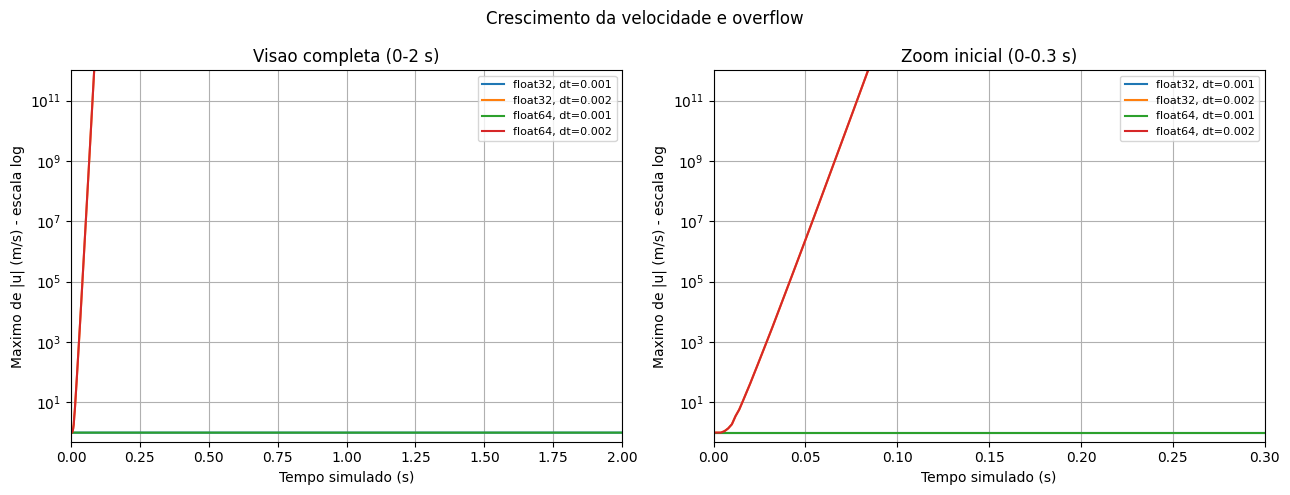

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for nome, resultado in resultados.items():
    axes[0].semilogy(resultado['tempos'], resultado['maximos'], label=nome)
    axes[1].semilogy(resultado['tempos'], resultado['maximos'], label=nome)
axes[0].set_ylim(0.5, 1e12); axes[0].set_xlim(0, 2)
axes[0].set_title('Visao completa (0-2 s)')
axes[1].set_ylim(0.5, 1e12); axes[1].set_xlim(0, 0.3)
axes[1].set_title('Zoom inicial (0-0.3 s)')
for ax in axes:
    ax.set_xlabel('Tempo simulado (s)')
    ax.set_ylabel('Maximo de |u| (m/s) - escala log')
    ax.grid(True)
    ax.legend(fontsize=8)
fig.suptitle('Crescimento da velocidade e overflow')
fig.tight_layout()
plt.show()


### Tabela de resultados

| Tipo numérico | $\Delta t$ (s) | $r$ | Overflow? | Passo da falha | Tempo da falha (s) |
|---|---|---|---|---|---|
| float32 | 0,001 | 0,4 | Não | – | – |
| float32 | 0,002 | 0,8 | **Sim** | 121 | 0,242 |
| float64 | 0,001 | 0,4 | Não | – | – |
| float64 | 0,002 | 0,8 | **Sim** | 917 | 1,834 |

O código a seguir apenas monta essa tabela automaticamente a partir do dicionário `resultados`.

In [ ]:
print(f"{'tipo':10s} {'dt':>8s} {'r':>8s} {'overflow?':>10s} {'passo falha':>12s}")
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        res = resultados[f'{tipo.__name__}, dt={dt}']
        ocorreu = 'SIM' if res['falha'] is not None else 'NAO'
        passo_f = res['falha'] if res['falha'] is not None else '-'
        print(f"{tipo.__name__:10s} {dt:8.3f} {res['r']:8.3f} {ocorreu:>10s} {str(passo_f):>12s}")


tipo             dt        r  overflow?  passo falha
float32       0.001    0.400        NAO            -
float32       0.002    0.800        SIM          121
float64       0.001    0.400        NAO            -
float64       0.002    0.800        SIM          917


## Atividade 3 — Interpretação física

Nos dois casos com $r=0{,}8$ (instáveis), o gráfico mostra `max|u|` crescendo **exponencialmente** — de 1 m/s para mais de $10^{300}$ m/s em menos de 2 segundos de tempo simulado, até estourar.

Isso não representa nenhum fenômeno físico real. Fisicamente, a velocidade do fluido está limitada pela condição de contorno: nenhum ponto do fluido pode se mover mais rápido que a placa que o arrasta, então $0 \le u(y,t) \le U = 1$ m/s em todo instante. Qualquer valor acima de 1 m/s já denuncia que a solução é espúria — um artefato puramente numérico, não uma previsão do modelo físico.

A causa é o coeficiente central da atualização, $1-2r$. Quando $r>1/2$, esse coeficiente fica negativo: a nova velocidade em um ponto passa a depender **negativamente** da velocidade dos vizinhos no passo anterior. Isso quebra a interpretação de "média ponderada" do esquema e faz qualquer erro de arredondamento (por menor que seja) ser amplificado a cada iteração, em vez de ser suavizado — dando origem a oscilações que crescem geometricamente, até ocorrer overflow.

## Atividade 4 — Capacidade de representação

**A mudança de tipo numérico NÃO elimina a instabilidade.** Em ambos os tipos, com $r=0{,}8$, a solução diverge exponencialmente da mesma forma — a *causa* da instabilidade é o esquema numérico (o valor de $r$), não o tipo de dado usado para armazenar os números.

O que muda entre `float32` e `float64` é **apenas quando o overflow aparece**:

- `float32` estoura no passo 121 ($t\approx 0{,}242$ s), pois seu maior valor representável é da ordem de $3{,}4\times10^{38}$;
- `float64` estoura muito mais tarde, no passo 917 ($t\approx 1{,}834$ s), pois seu limite é muito maior, da ordem de $1{,}8\times10^{308}$.

Como o crescimento é exponencial, dobrar (ou até multiplicar por vários fatores) o expoente máximo representável adia o estouro por bem mais passos, mas **não impede que ele ocorra**: a sequência de valores continua crescendo sem limite, então qualquer tipo de ponto flutuante, por maior que seja sua faixa, eventualmente estoura. `float64` só posterga o sintoma (overflow); não corrige a causa (instabilidade). Além disso, note que os valores de `max|u|` de `float32` e `float64` são praticamente idênticos até o momento em que `float32` estoura — o que confirma que a trajetória numérica é a mesma, só a "régua" de cada tipo é diferente.

## Atividade 5 — Refinamento da malha

Com `pontos=41`:

$$\Delta y = \frac{0{,}01}{41-1} = 0{,}00025\ \text{m}, \qquad \Delta t_{max} = \frac{(0{,}00025)^2}{2\times10^{-4}} = 3{,}125\times10^{-4}\ \text{s}$$

Refinar a malha (dobrar o número de pontos) **reduziu o $\Delta t_{max}$ por um fator de 4** (porque $\Delta t_{max}\propto \Delta y^2$, e $\Delta y$ caiu pela metade). Isso significa que o mesmo $\Delta t=0{,}001$ s que era estável na malha de 21 pontos ($r=0{,}4$) passa a ser fortemente instável na malha de 41 pontos: $r = 1{,}6$.

In [ ]:
pontos = 41
dy_novo = H / (pontos - 1)
dt_max_novo = dy_novo**2 / (2 * nu)
print(f'dy novo = {dy_novo} m')
print(f'dt_max novo = {dt_max_novo:.6e} s')

# Repetindo dt=0.001 (estavel na malha antiga) na malha refinada
res_instavel = simular(dt=0.001, tipo=np.float64, passos=2000, pontos=pontos)
print('r =', res_instavel['r'])


dy novo = 0.00025 m
dt_max novo = 3.125000e-04 s
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract
r = 1.6000000000000003


Como esperado, o resultado estoura rapidamente (por volta do passo 426, $t\approx0{,}426$ s), confirmando que a instabilidade não é uma propriedade fixa do problema, mas depende da relação entre $\Delta t$ e $\Delta y$. Agora escolhendo um passo de tempo abaixo do novo limite ($\Delta t_{max}=3{,}125\times10^{-4}$ s), por exemplo $\Delta t = 10^{-4}$ s ($r=0{,}16$):

dt=0.0001, float64: 20000 passos sem overflow.
r = 0.16 | falha: None


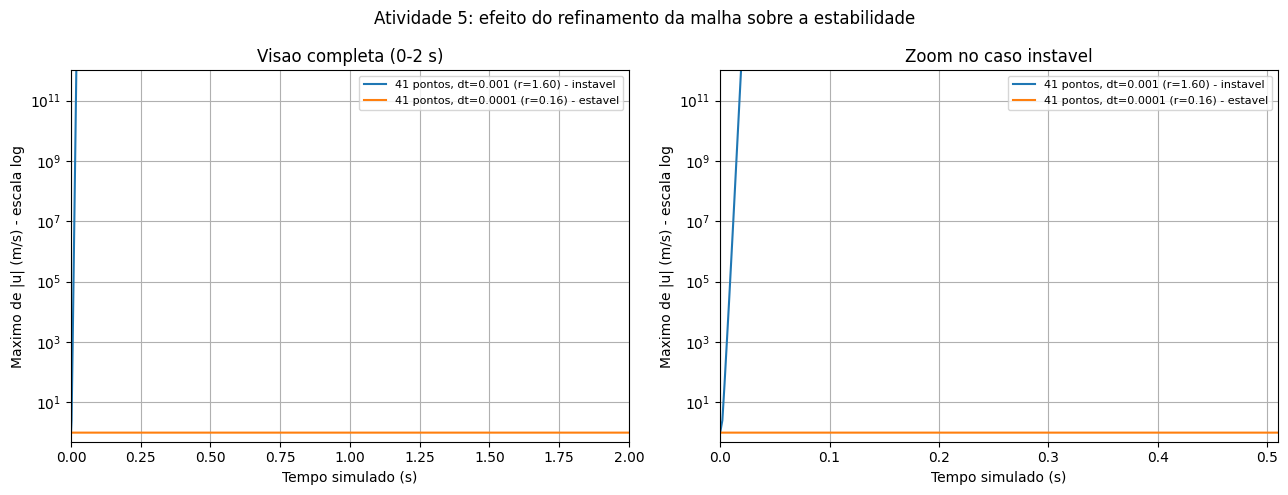

In [ ]:
dt_estavel = 0.0001  # abaixo de dt_max_novo = 3.125e-4 s
passos_estavel = 20000  # t_final = 2.0 s
res_estavel = simular(dt=dt_estavel, tipo=np.float64, passos=passos_estavel, pontos=pontos)
print('r =', res_estavel['r'], '| falha:', res_estavel['falha'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax in axes:
    ax.semilogy(res_instavel['tempos'], res_instavel['maximos'],
                label=f"41 pontos, dt=0.001 (r={res_instavel['r']:.2f}) - instavel")
    ax.semilogy(res_estavel['tempos'], res_estavel['maximos'],
                label=f"41 pontos, dt={dt_estavel} (r={res_estavel['r']:.2f}) - estavel")
    ax.set_ylim(0.5, 1e12)
    ax.set_xlabel('Tempo simulado (s)'); ax.set_ylabel('Maximo de |u| (m/s) - escala log')
    ax.grid(True); ax.legend(fontsize=8)
axes[0].set_xlim(0, 2.0); axes[0].set_title('Visao completa (0-2 s)')
axes[1].set_xlim(0, res_instavel['tempos'][-1]*1.2); axes[1].set_title('Zoom no caso instavel')
fig.suptitle('Atividade 5: efeito do refinamento da malha sobre a estabilidade')
fig.tight_layout()
plt.show()


Com $\Delta t = 10^{-4}$ s ($r=0{,}16 < 0{,}5$) a simulação completa os 20000 passos (2 s de tempo simulado) sem qualquer overflow, confirmando que o problema não estava na malha em si, mas na violação da condição $r\le 1/2$ ao manter o $\Delta t$ antigo em uma malha mais fina.

## Atividade 6 — Perfil final × solução estacionária

Usando a execução estável da atividade anterior (41 pontos, $\Delta t=10^{-4}$ s, $t_{final}=2$ s), comparamos o perfil final $u(y)$ com a solução estacionária $u_{est}(y) = U(1-y/H)$.

E_inf = 1.703e-09 m/s
t_final simulado = 2.00 s


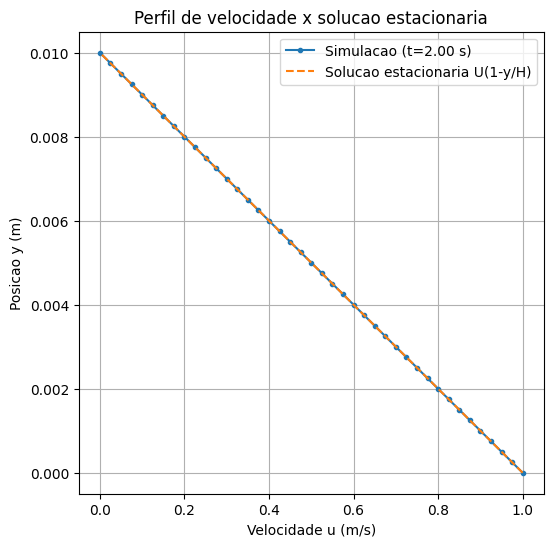

In [ ]:
y = res_estavel['y']
u_final = res_estavel['u']
u_estacionario = 1.0 * (1 - y / H)  # U = 1 m/s
erro = np.abs(u_final - u_estacionario)
E_inf = np.max(erro)
print(f'E_inf = {E_inf:.3e} m/s')
print(f't_final simulado = {res_estavel["tempos"][-1]:.2f} s')

plt.figure(figsize=(6, 6))
plt.plot(u_final, y, 'o-', markersize=3, label=f"Simulacao (t={res_estavel['tempos'][-1]:.2f} s)")
plt.plot(u_estacionario, y, '--', label='Solucao estacionaria U(1-y/H)')
plt.xlabel('Velocidade u (m/s)'); plt.ylabel('Posicao y (m)')
plt.title('Perfil de velocidade x solucao estacionaria')
plt.grid(True); plt.legend()
plt.show()


O erro máximo obtido foi $E_\infty \approx 1{,}7\times10^{-9}$ m/s — desprezível frente à escala do problema (velocidades da ordem de 1 m/s), e o perfil simulado é visualmente indistinguível da reta teórica.

O tempo característico de difusão viscosa neste problema é da ordem de $\tau \sim H^2/\nu = (0{,}01)^2/10^{-4} = 1$ s. Como o tempo total simulado ($t_{final}=2$ s) é o dobro desse tempo característico, o transiente já se dissipou quase completamente, e a diferença residual observada ($E_\infty$) reflete principalmente erro de truncamento numérico, não um transiente ainda em curso. Se o tempo simulado fosse muito menor que $\tau$ (por exemplo $t=0{,}01$ s), o perfil ainda estaria longe do regime estacionário e o erro em relação a $u_{est}(y)$ seria dominado pelo transiente, não pela precisão numérica.

## Atividade 7 — Conclusão

Os quatro conceitos investigados se relacionam da seguinte forma:

- **Refinamento da malha** (mais pontos → $\Delta y$ menor) **reduz** o passo de tempo máximo permitido, pois $\Delta t_{max}=\Delta y^2/(2\nu)$ cai com o quadrado de $\Delta y$. Refinar a malha sem ajustar $\Delta t$ é uma causa comum de instabilidade.
- **Instabilidade numérica** surge quando $r=\nu\Delta t/\Delta y^2 > 1/2$: o coeficiente central da atualização fica negativo, e pequenos erros de arredondamento são amplificados exponencialmente a cada passo, em vez de amortecidos.
- **Overflow** é apenas a consequência tardia e visível dessa amplificação: os valores crescem exponencialmente até ultrapassarem o maior número representável no tipo de ponto flutuante usado. Instabilidade e overflow **não são sinônimos** — a solução já está fisicamente errada (velocidades $>1$ m/s) muito antes de o overflow acontecer.
- Trocar `float32` por `float64` apenas **adia** o overflow (por ter uma faixa representável maior), mas não corrige a causa raiz.

**A alteração que de fato corrigiu a falha nesta simulação foi reduzir o passo de tempo** ($\Delta t$) até satisfazer $r\le 1/2$ para a malha utilizada — e não a troca de tipo numérico, nem qualquer outro ajuste.